In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
dataset = pd.read_csv('creditcard.csv')

In [26]:
print(dataset.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [27]:
dataset = dataset.drop("Time", axis=1)
X = dataset.drop("Class", axis=1)
y = dataset["Class"]

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

sc = StandardScaler()

X_train["Amount"] = sc.fit_transform(X_train[["Amount"]])
X_test["Amount"] = sc.transform(X_test[["Amount"]])

In [29]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', random_state=0)

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[71076     3]
 [   34    89]]
0.9994803516755147
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.97      0.72      0.83       123

    accuracy                           1.00     71202
   macro avg       0.98      0.86      0.91     71202
weighted avg       1.00      1.00      1.00     71202



In [31]:
from sklearn.metrics import roc_auc_score

y_prob = classifier.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.94953210769604


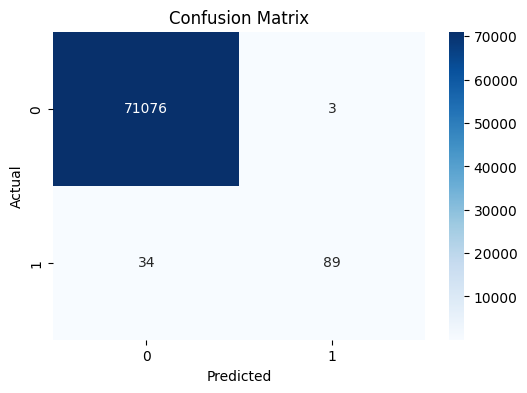

In [32]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()